In [ ]:
# Imports and global definitions

import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

processed_path = "https://connorwtech.com/resources/downloads/processed/"
interim_path = "https://connorwtech.com/resources/downloads/interim/"


# Load datasets

df_A = pd.read_csv(processed_path + 'df_A.csv')
df_B = pd.read_csv(processed_path + 'df_B.csv')
# Once df_2010.csv and df_2020.csv are on the server this can be replaced by the two lines below.
df_2010 = pd.read_csv(processed_path + 'df_X.csv')
# df_2010 = pd.read_csv(processed_path + 'df_2010.csv')
# df_2020 = pd.read_csv(processed_path + 'df_2020.csv
P = pd.read_csv(interim_path + "/countypres_2000-2024_interim.csv")

C10 = pd.read_csv(
    interim_path + "cc-est2019-alldata_interim.csv",
    encoding="latin1"
)

C20 = pd.read_csv(
    interim_path + "cc-est2023-alldata_interim.csv",
    encoding="latin1"
)


In [ ]:
# Load dataset df_B into df_2020 for transformations
# NOTE: IT IS INTENDED THAT THIS WILL BE EARLIER STANDALONE CODE, OR INTEGRATED INTO PRIOR CODE, TO CREATE df_2020.csv
# ALSO NOTE: it is intended that the current df_X.csv will be renamed as df_2010.csv; that should happen in the original generation code

# Once df_2020.csv is added to the server this section can be deleted

df_2020 = pd.read_csv(processed_path + 'df_B.csv')


# Combine female age groups by race

df_2020["NHWA_FEMALE_2034_share_X"] = (
    df_2020["NHWA_FEMALE_2024_C"] + df_2020["NHWA_FEMALE_2529_C"] + df_2020["NHWA_FEMALE_3034_C"]
    ) / (
    df_2020["TOT_FEMALE_2024_C"] + df_2020["TOT_FEMALE_2529_C"] + df_2020["TOT_FEMALE_3034_C"])

df_2020["NHBA_FEMALE_2034_share_X"] = (
    df_2020["NHBA_FEMALE_2024_C"] + df_2020["NHBA_FEMALE_2529_C"] + df_2020["NHBA_FEMALE_3034_C"]
    ) / (
    df_2020["TOT_FEMALE_2024_C"] + df_2020["TOT_FEMALE_2529_C"] + df_2020["TOT_FEMALE_3034_C"])

df_2020["H_FEMALE_2034_share_X"] = (
    df_2020["H_FEMALE_2024_C"] + df_2020["H_FEMALE_2529_C"] + df_2020["H_FEMALE_3034_C"]
    ) / (
    df_2020["TOT_FEMALE_2024_C"] + df_2020["TOT_FEMALE_2529_C"] + df_2020["TOT_FEMALE_3034_C"])


# Create race categories (default "Mixed")

df_2020["race_category_X"] = "Mixed"

df_2020.loc[df_2020["NHWA_FEMALE_2034_share_X"] >= 0.6, "race_category_X"] = "White"
df_2020.loc[df_2020["NHBA_FEMALE_2034_share_X"] >= 0.6, "race_category_X"] = "Black"
df_2020.loc[df_2020["H_FEMALE_2034_share_X"] >= 0.6, "race_category_X"] = "Hispanic"


# Create "regime" variable by combining political preference and race categories (default "Minority-majority")

df_2020["regime_X"] = "Minority_majority"

# White-majority
white_mask = df_2020["NHWA_FEMALE_2034_share_X"] >= 0.6

# Mixed
mixed_mask = df_2020["race_category_X"] == "Mixed"

# Political classification
df_2020["pol_group_X"] = "Competitive"
df_2020.loc[df_2020["dem2020_P"] <= 0.4, "pol_group_X"] = "Republican"
df_2020.loc[df_2020["dem2020_P"] >= 0.6, "pol_group_X"] = "Democratic"

# Assign regimes
df_2020.loc[white_mask & (df_2020["pol_group_X"] == "Republican"), "regime_X"] = "White_Republican"
df_2020.loc[white_mask & (df_2020["pol_group_X"] == "Democratic"), "regime_X"] = "White_Democratic"
df_2020.loc[white_mask & (df_2020["pol_group_X"] == "Competitive"), "regime_X"] = "White_Competitive"

df_2020.loc[mixed_mask & (df_2020["pol_group_X"] == "Republican"), "regime_X"] = "Mixed_Republican"
df_2020.loc[mixed_mask & (df_2020["pol_group_X"] == "Democratic"), "regime_X"] = "Mixed_Democratic"
df_2020.loc[mixed_mask & (df_2020["pol_group_X"] == "Competitive"), "regime_X"] = "Mixed_Competitive"


# One-hot encoding

df_2020 = df_2020.loc[:, ~df_2020.columns.str.startswith("reg_")]

regime_dummies = pd.get_dummies(df_2020["regime_X"], prefix="reg")

regime_dummies.columns = regime_dummies.columns + '_X'

# Attach to df_2020
df_2020 = pd.concat([df_2020, regime_dummies], axis=1)

In [8]:
# normalize fips
df_2010["fips"] = df_2010["fips"].astype(str).str.zfill(5)
df_2020["fips"] = df_2020["fips"].astype(str).str.zfill(5)
df_B["fips"]    = df_B["fips"].astype(str).str.zfill(5)

# Update names from P
P_tmp = P[["county_fips", "state", "county_name"]].copy()
P_tmp["fips"] = P_tmp["county_fips"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
P_tmp = P_tmp.drop(columns=["county_fips"]).drop_duplicates("fips")

P_tmp["state"] = P_tmp["state"].astype(str).str.title()
P_tmp["county"] = P_tmp["county_name"].astype(str).str.title()
P_tmp = P_tmp.drop(columns=["county_name"])

# eliminate superfluous information from bases
base_2010 = df_2010[["fips", "birth_rate_2010_N", "birth_rate_2020_N", "regime_X"]].copy()
base_2010 = base_2010.rename(columns={"regime_X": "regime_2010"})

base_2020 = df_2020[["fips", "regime_X"]].copy()
base_2020 = base_2020.rename(columns={"regime_X": "regime_2020"})

br_2020 = df_2020[["fips", "birth_rate_2020_N"]].copy()

# 2010 population lookup
pop10 = C10[
    (C10["SUMLEV"] == 50) &
    (C10["AGEGRP"] == 0)
][["STATE", "COUNTY", "TOT_POP"]].copy()

pop10["fips"] = (
    pop10["STATE"].astype(int).astype(str).str.zfill(2) +
    pop10["COUNTY"].astype(int).astype(str).str.zfill(3)
)

pop10 = pop10.rename(columns={"TOT_POP": "pop_2010"})
pop10 = pop10[["fips", "pop_2010"]]


# 2020 population
pop20 = C20[
    (C20["SUMLEV"] == 50) &
    (C20["AGEGRP"] == 0)
][["STATE", "COUNTY", "TOT_POP"]].copy()

pop20["fips"] = (
    pop20["STATE"].astype(int).astype(str).str.zfill(2) +
    pop20["COUNTY"].astype(int).astype(str).str.zfill(3)
)

pop20 = pop20.rename(columns={"TOT_POP": "pop_2020"})
pop20 = pop20[["fips", "pop_2020"]]

# build df_app as overall singular df
df_app = (
    base_2010
    .merge(base_2020, on="fips", how="left")
    .merge(br_2020, on="fips", how="left", suffixes=("", "_from_B"))
    .merge(P_tmp, on="fips", how="left")
)

df_app = df_app.merge(pop10, on="fips", how="left")
df_app = df_app.merge(pop20, on="fips", how="left")

# if df_2010 already had birth_rate_2020_N, keep it; otherwise use df_B version
#if "birth_rate_2020_N" not in df_app.columns or df_app["birth_rate_2020_N"].isna().all():
#    df_app["birth_rate_2020_N"] = df_app["birth_rate_2020_N_from_B"]

# cleanup helper column if present
#if "birth_rate_2020_N_from_B" in df_app.columns:
#    df_app = df_app.drop(columns=["birth_rate_2020_N_from_B"])

# build dropdown label
df_app["dropdown_label"] = df_app["state"] + " - " + df_app["county"]

# final column order
df_app = df_app[
    ["fips", "dropdown_label", "state", "county",
     "pop_2010", "pop_2020",
     "regime_2010", "regime_2020",
     "birth_rate_2010_N", "birth_rate_2020_N"
    ]
].copy()

# -------------------------
# 1) Fit model on 2010 -> 2020
# -------------------------

train = df_2010.dropna(subset=["birth_rate_2010_N", "birth_rate_2020_N"]).copy()

reg_cols = [
    "reg_Minority_majority_X",
    "reg_Mixed_Competitive_X",
    "reg_Mixed_Democratic_X",
    "reg_Mixed_Republican_X",
    "reg_White_Competitive_X",
    "reg_White_Democratic_X",
    "reg_White_Republican_X",
]

# dummies --> numeric 0/1
for c in reg_cols:
    train[c] = train[c].astype(int)

# drop one reference dummy
ref = "reg_White_Competitive_X"
reg_cols_model = [c for c in reg_cols if c != ref]

terms_main = " + ".join([f'Q("{c}")' for c in reg_cols_model])
terms_int  = " + ".join([f'birth_rate_2010_N:Q("{c}")' for c in reg_cols_model])

formula = f'birth_rate_2020_N ~ birth_rate_2010_N + {terms_main} + {terms_int}'

fit = smf.ols(formula, data=train).fit()

# -------------------------
# 2) Predict 2030 using 2020 as the baseline
#    (using 2010->2020)
# -------------------------

pred = df_2020.dropna(subset=["birth_rate_2020_N"]).copy()

# dummies --> numeric 0/1
for c in reg_cols:
    pred[c] = pred[c].astype(int)

# use model on 2020 data
pred["birth_rate_2010_N"] = pred["birth_rate_2020_N"]

pred["birth_rate_2030_pred"] = fit.predict(pred)

# Get prediction object
pred_results = fit.get_prediction(pred)

pred_summary = pred_results.summary_frame(alpha=0.05)

# add prediction to 2020 df
df_2020["birth_rate_2030_pred"] = pred_summary["mean"]
df_2020["birth_rate_2030_ci_lower"] = pred_summary["obs_ci_lower"]
df_2020["birth_rate_2030_ci_upper"] = pred_summary["obs_ci_upper"]

# update df_app
proj_cols = [
    "fips",
    "birth_rate_2030_pred",
    "birth_rate_2030_ci_lower",
    "birth_rate_2030_ci_upper"
]

df_app = df_app.merge(
    df_2020[proj_cols],
    on="fips",
    how="left"
)

In [9]:
def nearest_lists(                # closest entities by projected birth rate
    df_app: pd.DataFrame,
    selected_fips: str,
    rate_col: str = "birth_rate_2030_pred",
    regime_col: str = "regime_2020",
    k: int = 5
):
    df = df_app.copy()
    df["fips"] = df["fips"].astype(str).str.zfill(5)
    selected_fips = str(selected_fips).zfill(5)

    if selected_fips not in set(df["fips"]):
        raise ValueError(f"selected_fips {selected_fips} not found")

    df[rate_col] = pd.to_numeric(df[rate_col], errors="coerce")

    target = df.loc[df["fips"] == selected_fips].iloc[0]
    target_rate = target[rate_col]

    cand = df.dropna(subset=[rate_col]).copy()
    cand["abs_diff"] = (cand[rate_col] - target_rate).abs()

    # closest k, then display in numerical order by rate
    overall = (
        cand.sort_values("abs_diff")
            .head(k)
            .sort_values(rate_col)
            .copy()
    )

    same = None
    if regime_col in df.columns and pd.notna(target[regime_col]):
        same_reg = cand[cand[regime_col] == target[regime_col]].copy()
        same = (
            same_reg.sort_values("abs_diff")
                    .head(k)
                    .sort_values(rate_col)
                    .copy()
        )

    def format_out(d):
        if d is None:
            return None
        out = d[["fips", "state", "county", rate_col, "abs_diff"]].copy()
        out["label"] = out["state"].astype(str) + " - " + out["county"].astype(str)
        out["is_selected"] = (out["fips"] == selected_fips).astype(int)
        out = out.rename(columns={rate_col: "rate"})
        return out[["label", "rate", "is_selected"]].reset_index(drop=True)

    return target, format_out(overall), format_out(same)

# county data we want displayed
def county_report(df_app: pd.DataFrame, selection: str, k: int = 5, rate_col: str = "birth_rate_2030_pred"):
    """
    selection can be either:
      - fips (e.g., '49057')
      - dropdown_label (e.g., 'Utah - Weber')
    Returns a dict with the selected county details + two neighbor tables.
    """

    df = df_app.copy()
    df["fips"] = df["fips"].astype(str).str.zfill(5)

    # Resolve selection -> fips
    s = str(selection).strip()

    if s.isdigit() and len(s) <= 5:
        selected_fips = s.zfill(5)
    else:
        # assume dropdown label
        matches = df[df["dropdown_label"].astype(str).str.lower() == s.lower()]
        if matches.empty:
            # fail-safe
            matches = df[df["dropdown_label"].astype(str).str.lower().str.contains(s.lower(), na=False)]
        if len(matches) != 1:
            raise ValueError(f"Selection '{selection}' matched {len(matches)} counties; need exactly 1.")
        selected_fips = matches.iloc[0]["fips"]

    target, nearest_any, nearest_same = nearest_lists(
        df_app=df,
        selected_fips=selected_fips,
        rate_col=rate_col,
        regime_col="regime_2020",
        k=k
    )

    # panel of values
    panel = {
        "State": target.get("state", None),
        "County": target.get("county", None),
        "FIPS": target.get("fips", None),
        "2010 population": int(target["pop_2010"]) if pd.notna(target.get("pop_2010", np.nan)) else None,
        "2010 Socio-Political Category": target.get("regime_2010", None),
        "2020 population": int(target["pop_2020"]) if pd.notna(target.get("pop_2020", np.nan)) else None,
        "2020 Socio-Political Category": target.get("regime_2020", None),
        "2010 birth rate": float(target["birth_rate_2010_N"]) if pd.notna(target.get("birth_rate_2010_N", np.nan)) else None,
        "2020 birth rate": float(target["birth_rate_2020_N"]) if pd.notna(target.get("birth_rate_2020_N", np.nan)) else None,
        "2030 birth rate (projected)": float(target["birth_rate_2030_pred"]) if pd.notna(target.get("birth_rate_2030_pred", np.nan)) else None,
        "2030 projection (95% lower)": float(target["birth_rate_2030_ci_lower"]) if pd.notna(target.get("birth_rate_2030_ci_lower", np.nan)) else None,
        "2030 projection (95% upper)": float(target["birth_rate_2030_ci_upper"]) if pd.notna(target.get("birth_rate_2030_ci_upper", np.nan)) else None,
    }

    result = {
        "panel": panel,
        "nearest_any": nearest_any,
        "nearest_same_regime": nearest_same
    }
    return result

# display county report
def print_county_report(report: dict):
    panel = report["panel"]
    print("\n=== County Profile ===")
    for k, v in panel.items():
        print(f"{k}: {v}")

    print("\n=== 5 Closest Counties (any) by projected 2030 birth rate ===")
    print(report["nearest_any"])

    print("\n=== 5 Closest Counties (same socio-political category) by projected 2030 birth rate ===")
    ns = report["nearest_same_regime"]
    print(ns if ns is not None else "(No regime match info available)")

# county plot addendum
def plot_county_trend_with_cone(df_app: pd.DataFrame, selection: str):
    df = df_app.copy()
    df["fips"] = df["fips"].astype(str).str.zfill(5)

    # Resolve selection -> fips
    s = str(selection).strip()
    if s.isdigit() and len(s) <= 5:
        fips = s.zfill(5)
    else:
        m = df[df["dropdown_label"].astype(str).str.lower() == s.lower()]
        if m.empty:
            m = df[df["dropdown_label"].astype(str).str.lower().str.contains(s.lower(), na=False)]
        if len(m) != 1:
            raise ValueError(f"Selection '{selection}' matched {len(m)} counties; need exactly 1.")
        fips = m.iloc[0]["fips"]

    row = df.loc[df["fips"] == fips].iloc[0]

    # Values
    y2010 = row["birth_rate_2010_N"]
    y2020 = row["birth_rate_2020_N"]
    y2030 = row["birth_rate_2030_pred"]
    lo2030 = row["birth_rate_2030_ci_lower"]
    hi2030 = row["birth_rate_2030_ci_upper"]

    years = [2010, 2020, 2030]
    vals  = [y2010, y2020, y2030]

    plt.figure(figsize=(8, 5))

    # Actual
    plt.plot([2010, 2020], [y2010, y2020], marker="o")

    # Forecast (dashed)
    plt.plot([2020, 2030], [y2020, y2030], marker="o", linestyle="--")

    # Projection cone
    plt.fill_between(
        [2020, 2030],
        [y2020, lo2030],
        [y2020, hi2030],
        alpha=0.15
    )

    plt.title(f"{row['state']} - {row['county']} Birth Rate Trend")
    plt.xlabel("Year")
    plt.ylabel("Birth Rate (per 1,000)")
    plt.xticks([2010, 2020, 2030])
    plt.grid(True, alpha=0.3)
    plt.show()

st_cnt = "Utah - Weber"
rep = county_report(df_app, st_cnt, k=5, rate_col="birth_rate_2030_pred")
print_county_report(rep)


=== County Profile ===
State: Utah
County: Weber
FIPS: 49057
2010 population: 231236
2010 Socio-Political Category: White_Republican
2020 population: 262218
2020 Socio-Political Category: White_Republican
2010 birth rate: 17.64
2020 birth rate: 13.58
2030 birth rate (projected): 11.520221310851326
2030 projection (95% lower): 9.912082971388454
2030 projection (95% upper): 13.128359650314199

=== 5 Closest Counties (any) by projected 2030 birth rate ===
                 label       rate  is_selected
0       Idaho - Canyon  11.461017            0
1  California - Fresno  11.495853            0
2         Utah - Weber  11.520221            1
3       Georgia - Bibb  11.521683            0
4       Texas - Taylor  11.574410            0

=== 5 Closest Counties (same socio-political category) by projected 2030 birth rate ===
                   label       rate  is_selected
0  Louisiana - Calcasieu  11.211042            0
1           Utah - Davis  11.421547            0
2         Idaho - Canyon

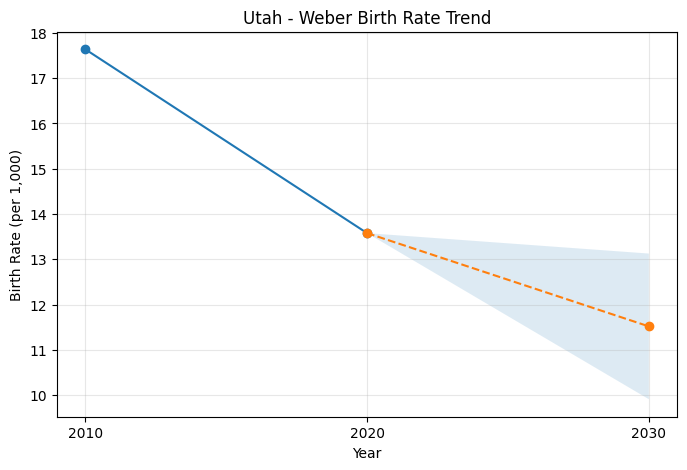

In [10]:
plot_county_trend_with_cone(df_app, st_cnt)